# Notebook 3: NumPy Random Module

**Sprint 3: NumPy & Pandas for AI/ML Engineers**

---

## What is the NumPy Random Module?

The random module (`np.random`) creates **random numbers** and does **random operations** (picking, shuffling, sampling) on arrays. Computers cannot be truly random, so NumPy uses **pseudo-random numbers**: numbers that look random but come from a formula that starts at a **seed**. The same seed always gives the same sequence.

**Analogy:** A shuffled playlist. It looks random, but if you could reset it to the same starting point, it would play the same order again. The seed is that starting point.

**Real-world example:** Simulating 1000 dice rolls, or drawing a lucky-draw winner.

**Business example:** A company randomly picks 500 customers for a survey, or simulates 10,000 possible monthly sales to estimate the risk (Monte Carlo simulation).

**AI/ML example:**
- **Train-test split** shuffles the rows randomly.
- **Weight initialization** of neural networks uses random numbers.
- **Bootstrapping** (Random Forest) samples rows with replacement.
- **Mini-batches** are picked randomly in every epoch.
- **Reproducibility:** a fixed seed lets others get the same results.

**Topics covered:** Random Numbers, Random Seed, Random Integers, Random Choice, Shuffle, Permutation, Random Distributions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.4.6


## 1. Random Numbers

| Function | What it gives |
|---|---|
| `np.random.rand(d1, d2)` | Uniform random floats in [0, 1) |
| `np.random.randn(d1, d2)` | Standard normal numbers (mean 0, std 1) |
| `np.random.random(size)` | Same as `rand`, but takes a shape tuple |
| `a + (b - a) * np.random.rand()` | Random float between a and b |

**Two APIs in NumPy:**
- **Legacy API:** `np.random.seed(...)`, `np.random.rand(...)`. Simple, uses one global generator.
- **Modern API (recommended):** `rng = np.random.default_rng(seed)`, then `rng.random(...)`, `rng.integers(...)`. Each `rng` is independent, so it is safer in bigger projects.

**Numerical example:** `rand()` can give 0.37, and a random price between 100 and 200 is `100 + 100 * 0.37 = 137`.

**Business example:** Generating random discount coupons or random delivery times for a simulation.

**AI/ML example:** `np.random.randn(784, 128) * 0.01` creates small random weights for a layer with 784 inputs and 128 neurons.

In [2]:
print("rand()       :", np.random.rand())
print("rand(3)      :", np.random.rand(3))
print("rand(2, 3):\n", np.random.rand(2, 3))
print("randn(3)     :", np.random.randn(3))

# Random floats between 100 and 200
prices = 100 + 100 * np.random.rand(5)
print("\nPrices between 100 and 200:", prices.round(2))

# Modern API
rng = np.random.default_rng(42)
print("\nrng.random(3)  :", rng.random(3))
print("rng.normal(0, 1, 3):", rng.normal(0, 1, 3))

# AI/ML: small random weights for a layer
W = np.random.randn(4, 3) * 0.01
print("\nWeights shape:", W.shape, "| max abs value:", np.abs(W).max().round(4))

rand()       : 0.7456363555702449
rand(3)      : [0.97972841 0.135929   0.77884937]
rand(2, 3):
 [[0.07196004 0.33424545 0.53352828]
 [0.82801437 0.09563357 0.19351777]]
randn(3)     : [-1.43165264 -0.79502916  2.59173755]

Prices between 100 and 200: [188.03 188.43 193.83 162.34 154.15]

rng.random(3)  : [0.77395605 0.43887844 0.85859792]
rng.normal(0, 1, 3): [ 0.94056472 -1.95103519 -1.30217951]

Weights shape: (4, 3) | max abs value: 0.0269


**Output Explanation:**
- `rand()` gives a single float between 0 and 1, and `rand(2, 3)` gives a 2 x 3 array.
- `randn` numbers are centered at 0 and can be negative.
- `100 + 100 * rand` stretches 0 to 1 into 100 to 200.
- The weights are tiny numbers (close to 0) because we multiplied by 0.01. Starting with small random values lets each neuron learn something different.
- Your numbers will be different from mine, because we did not fix the seed yet. That is the next topic.

## 2. Random Seed

A **seed** is the starting number of the random generator. **Same seed gives the same random numbers every time**, on any run and on any machine (for the same NumPy version and generator).

| Code | Style |
|---|---|
| `np.random.seed(42)` | Legacy, sets the global generator |
| `rng = np.random.default_rng(42)` | Modern, creates a separate generator |

**Analogy:** Opening a book at page 42. Every time you do it, you read the same page.

**Business example:** An analyst shares a simulation with the manager. With a fixed seed, the manager sees exactly the same numbers and can check the result.

**AI/ML example:** **Reproducibility.** Fixing the seed makes the train-test split, weight initialization and model results repeatable, so we can compare two models fairly. Researchers always report the seed.

**Note:** 42 is only a popular convention. Any integer works.

In [3]:
np.random.seed(42)
first = np.random.rand(3)

np.random.seed(42)
second = np.random.rand(3)

print("First run :", first)
print("Second run:", second)
print("Same?     :", np.array_equal(first, second))

# Without resetting the seed, the sequence continues
np.random.seed(42)
a = np.random.rand(3)
b = np.random.rand(3)
print("\nNext 3 numbers without reseed:", b, "| same as a?", np.array_equal(a, b))

# Different seed, different numbers
np.random.seed(7)
print("Seed 7:", np.random.rand(3))

# Modern API: independent generators
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)
print("\nTwo generators with the same seed:", rng1.random(2), rng2.random(2))

First run : [0.37454012 0.95071431 0.73199394]
Second run: [0.37454012 0.95071431 0.73199394]
Same?     : True

Next 3 numbers without reseed: [0.59865848 0.15601864 0.15599452] | same as a? False
Seed 7: [0.07630829 0.77991879 0.43840923]

Two generators with the same seed: [0.68235186 0.05382102] [0.68235186 0.05382102]


**Output Explanation:**
- Setting `seed(42)` before each call gives **identical** arrays (the first value is about 0.3745).
- Without re-seeding, the generator **continues** the sequence, so `a` and `b` are different.
- A different seed (7) gives different numbers.
- Two modern generators created with the same seed give the same numbers independently.
- **Important:** set the seed once at the **top** of the notebook, not before every line.

## 3. Random Integers

| Function | Meaning |
|---|---|
| `np.random.randint(low, high, size)` | Random integers from `low` up to **high - 1** (high is excluded) |
| `rng.integers(low, high, size)` | Modern version (high excluded by default) |
| `rng.integers(low, high, size, endpoint=True)` | Includes `high` |

**Numerical example:** A die has faces 1 to 6, so `randint(1, 7)`. Writing `randint(1, 6)` is a common mistake, it never gives 6.

**Real-world example:** Rolling dice, picking random roll numbers.

**Business example:** Generating random customer ages, order quantities or test data for an application.

**AI/ML example:** Creating random class labels for testing, random indices for mini-batches, and random seeds themselves.

In [4]:
np.random.seed(42)

print("One die roll     :", np.random.randint(1, 7))
rolls = np.random.randint(1, 7, size=10)
print("10 die rolls     :", rolls)
print("2 x 4 integers:\n", np.random.randint(0, 100, size=(2, 4)))

# Check the high value is excluded
big = np.random.randint(1, 7, size=100000)
print("\nMin:", big.min(), "| Max:", big.max())

# Is the die fair? Count each face
faces, counts = np.unique(big, return_counts=True)
print("Face counts:", dict(zip(faces, counts)))

# Modern API with endpoint
rng = np.random.default_rng(42)
print("\nrng.integers(1, 6, endpoint=True):", rng.integers(1, 6, size=8, endpoint=True))

# Random test data
ages = np.random.randint(18, 60, size=5)
qty = np.random.randint(1, 11, size=5)
print("\nAges:", ages, "| Quantities:", qty)

# Random mini-batch indices
X = np.arange(100)
batch_idx = np.random.randint(0, len(X), size=8)
print("Batch indices:", batch_idx)

One die roll     : 4
10 die rolls     : [5 3 5 5 2 3 3 3 5 4]
2 x 4 integers:
 [[23  2 21 52]
 [ 1 87 29 37]]

Min: 1 | Max: 6
Face counts: {np.int32(1): np.int64(16593), np.int32(2): np.int64(16800), np.int32(3): np.int64(16387), np.int32(4): np.int64(16777), np.int32(5): np.int64(16811), np.int32(6): np.int64(16632)}

rng.integers(1, 6, endpoint=True): [1 5 4 3 3 6 1 5]

Ages: [45 40 56 47 53] | Quantities: [ 6  7 10  4  9]
Batch indices: [88 19 71 23 81 37 72 23]


**Output Explanation:**
- `randint(1, 7)` gives numbers from 1 to **6**. The max over 100,000 rolls is 6, and 7 never appears.
- Each face appears about 16,667 times, which shows the die is fair (uniform).
- With `endpoint=True`, `rng.integers(1, 6)` includes 6 as well.
- `randint` picks with **repetition**, so the same index can appear twice in the batch. For unique picks, we use `choice(..., replace=False)` or `permutation`.

## 4. Random Choice

`np.random.choice(a, size, replace, p)` picks random items **from an existing array or list**.

| Parameter | Meaning |
|---|---|
| `a` | Array to pick from (or an integer n, which means `range(n)`) |
| `size` | How many items to pick |
| `replace=True` | Same item can be picked again (default) |
| `replace=False` | Each item can be picked only once |
| `p` | Probability of each item (must add up to 1) |

**Analogy:** `replace=True` is picking a ball from a bag and putting it back. `replace=False` is keeping the ball out.

**Business example:** Randomly choosing 3 winners from 100 customers (`replace=False`), or simulating customer segments with 60% Regular, 30% Premium and 10% VIP (using `p`).

**AI/ML example:**
- **Sampling** rows for a smaller dataset.
- **Bootstrap sample** (`replace=True`) used in Random Forest.
- **Class-weighted sampling** for imbalanced data.
- Random action selection in reinforcement learning (exploration).

In [5]:
np.random.seed(42)
colors = np.array(["red", "green", "blue", "yellow"])

print("One pick           :", np.random.choice(colors))
print("3 picks with replace:", np.random.choice(colors, size=3))
print("3 picks no replace  :", np.random.choice(colors, size=3, replace=False))

# More picks than items without replacement fails
try:
    np.random.choice(colors, size=10, replace=False)
except ValueError as e:
    print("\nError:", e)

# Weighted choice
segments = np.random.choice(["Regular", "Premium", "VIP"], size=10000, p=[0.6, 0.3, 0.1])
names, counts = np.unique(segments, return_counts=True)
print("\nSegment share:", dict(zip(names, (counts / counts.sum()).round(3))))

# Lucky draw: 3 unique winners from 100 customers
customers = np.arange(1, 101)
print("Winners:", np.random.choice(customers, size=3, replace=False))

# Bootstrap sample (same size, with replacement)
data = np.array([10, 20, 30, 40, 50])
boot = np.random.choice(data, size=len(data), replace=True)
print("\nBootstrap sample:", boot)

# Bootstrap estimate of the mean's uncertainty
means = [np.random.choice(data, size=len(data), replace=True).mean() for _ in range(2000)]
print("Mean of bootstrap means:", round(np.mean(means), 2), "| Std:", round(np.std(means), 2))

One pick           : blue
3 picks with replace: ['yellow' 'red' 'blue']
3 picks no replace  : ['green' 'yellow' 'red']

Error: Cannot take a larger sample than population when 'replace=False'

Segment share: {np.str_('Premium'): np.float64(0.293), np.str_('Regular'): np.float64(0.611), np.str_('VIP'): np.float64(0.096)}
Winners: [49 32 12]

Bootstrap sample: [40 30 40 20 30]
Mean of bootstrap means: 29.76 | Std: 6.43


**Output Explanation:**
- `replace=True` can repeat a colour, and `replace=False` never repeats.
- Asking for 10 items from 4 **without** replacement raises a `ValueError`, because there are not enough items.
- With `p=[0.6, 0.3, 0.1]` the shares come out close to 0.6, 0.3 and 0.1 (not exact, because it is random).
- The bootstrap sample has 5 values taken from the original, and some values can repeat while others are missing. Repeating it 2000 times gives a mean close to 30, and the std tells us how uncertain the mean is. This is the idea behind Random Forest and **bootstrap confidence intervals**.

## 5. Shuffle and Permutation

Both put the items in a **random order**, but they work differently.

| | `np.random.shuffle(a)` | `np.random.permutation(a)` |
|---|---|---|
| Changes the original? | **Yes, in place** | **No**, returns a new shuffled copy |
| Returns | `None` | A new array |
| Input can be an integer? | No | Yes: `permutation(5)` shuffles `0..4` |
| 2D arrays | Shuffles the **rows** | Shuffles the **rows** |

**Analogy:** `shuffle` is shuffling your own deck of cards (the deck is changed). `permutation` is making a shuffled duplicate deck and leaving the original alone.

**Business example:** Randomizing the order of questions in an online test, or the order of customers to call.

**AI/ML example:**
- **Shuffling the training data every epoch** so the model does not learn the order of the rows.
- **Train-test split:** shuffle the row indices, then take the first 80% for training and the rest for testing.
- Keeping `X` and `y` aligned while shuffling: shuffle the **indices** once and use them for both.

**Common mistake:** `a = np.random.shuffle(a)` makes `a` equal to `None`.

In [6]:
np.random.seed(42)

a = np.arange(10)
np.random.shuffle(a)                 # in place
print("After shuffle (original changed):", a)

b = np.arange(10)
p = np.random.permutation(b)         # new array
print("\nOriginal b    :", b)
print("Permutation p :", p)

print("permutation(5):", np.random.permutation(5))

# The None mistake
x = np.arange(5)
result = np.random.shuffle(x)
print("\nReturn value of shuffle:", result)

# Shuffling a 2D array shuffles rows only
m = np.arange(12).reshape(4, 3)
print("\nOriginal matrix:\n", m)
print("Shuffled rows:\n", np.random.permutation(m))

# Keep X and y aligned by shuffling the indices
X = np.array([[1, 10], [2, 20], [3, 30], [4, 40], [5, 50]])
y = np.array([0, 0, 1, 1, 1])
idx = np.random.permutation(len(X))
X_shuffled, y_shuffled = X[idx], y[idx]
print("\nIndices:", idx)
print("X shuffled:\n", X_shuffled)
print("y shuffled:", y_shuffled)

# Manual train-test split (80/20)
np.random.seed(42)
data = np.arange(100)
idx = np.random.permutation(len(data))
split = int(0.8 * len(data))
train, test = data[idx[:split]], data[idx[split:]]
print("\nTrain size:", len(train), "| Test size:", len(test))
print("Overlap between train and test:", np.intersect1d(train, test).size)

After shuffle (original changed): [8 1 5 0 7 2 9 4 3 6]

Original b    : [0 1 2 3 4 5 6 7 8 9]
Permutation p : [0 1 8 5 3 4 7 9 6 2]
permutation(5): [0 2 3 1 4]

Return value of shuffle: None

Original matrix:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
Shuffled rows:
 [[ 0  1  2]
 [ 6  7  8]
 [ 3  4  5]
 [ 9 10 11]]

Indices: [1 2 0 3 4]
X shuffled:
 [[ 2 20]
 [ 3 30]
 [ 1 10]
 [ 4 40]
 [ 5 50]]
y shuffled: [0 1 0 1 1]

Train size: 80 | Test size: 20
Overlap between train and test: 0


**Output Explanation:**
- `shuffle` changed `a` itself. `permutation` left `b` untouched and returned a new array `p`.
- `shuffle` returns `None`, so writing `x = np.random.shuffle(x)` would destroy your data.
- For a 2D array, whole **rows** move together, and the values inside each row stay in the same order.
- Using the same `idx` for `X` and `y` keeps each sample with its own label. Shuffling them separately would break the match (a serious bug).
- The manual split gives 80 train and 20 test rows, and the overlap is **0**, which means no row is in both sets (no data leakage).

## 6. Random Distributions

NumPy can generate random numbers that follow the **probability distributions** from Sprint 2.

| Function | Distribution | Parameters | Used for |
|---|---|---|---|
| `np.random.uniform(low, high, size)` | Uniform | low, high | Every value equally likely |
| `np.random.normal(loc, scale, size)` | Normal (Gaussian) | mean, std | Heights, errors, many natural data |
| `np.random.binomial(n, p, size)` | Binomial | trials, probability | Number of successes in n trials |
| `np.random.poisson(lam, size)` | Poisson | average rate | Events per time interval |
| `np.random.exponential(scale, size)` | Exponential | scale = 1 / rate | Waiting time between events |
| `np.random.choice(..., p=...)` | Custom discrete | probabilities | Custom categories |

**Real-world examples:**
- Normal: heights with mean 170 and std 10.
- Binomial: number of heads in 10 coin tosses.
- Poisson: number of calls per hour (average 4).
- Exponential: time until the next call.

**Business example:** Simulating daily demand with a normal distribution, customer arrivals with Poisson, and the time between arrivals with exponential, to plan staff and stock.

**AI/ML example:**
- **Synthetic data** generation for testing and for practice.
- **Weight initialization:** normal (He, Xavier) or uniform.
- **Adding noise** to data (Gaussian noise) for augmentation.
- **Monte Carlo simulation** for risk and for Bayesian methods.
- Checking an algorithm on data where we **know the truth**.

Uniform(0,10)  -> mean: 4.94 (theory 5)
Normal(170,10) -> mean: 170.12 | std: 10.0 (theory 170, 10)
Binomial(10,.5)-> mean: 4.99 (theory 5)
Poisson(4)     -> mean: 4.02 | var: 4.04 (theory 4, 4)
Exponential    -> mean: 0.25 (theory 0.25)


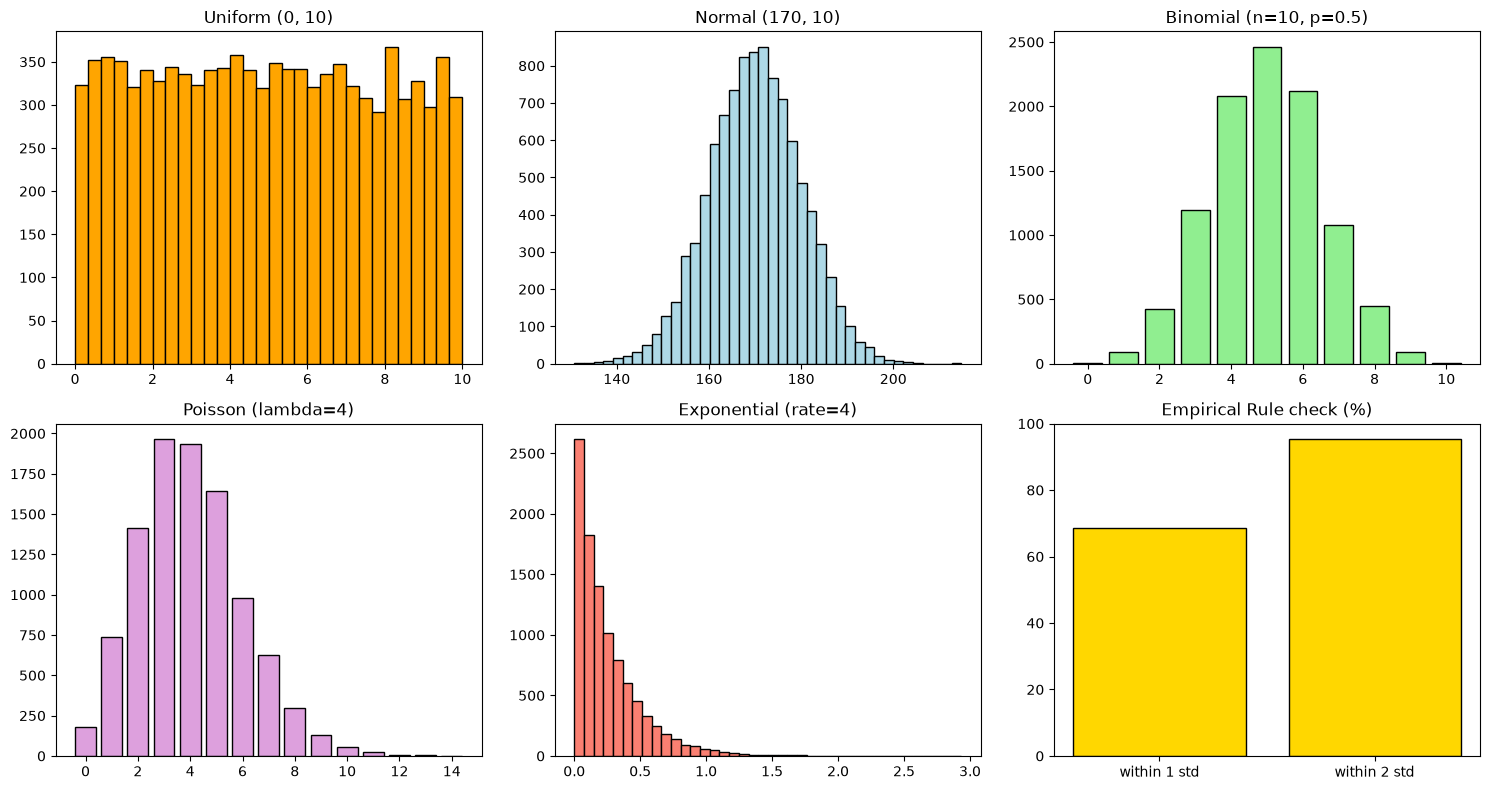


Within 1 std: 68.6% | Within 2 std: 95.5%


In [7]:
np.random.seed(42)
n = 10000

uniform_data = np.random.uniform(0, 10, n)
normal_data = np.random.normal(170, 10, n)
binom_data = np.random.binomial(10, 0.5, n)
poisson_data = np.random.poisson(4, n)
expo_data = np.random.exponential(scale=1/4, size=n)     # rate 4 per hour -> mean wait 0.25 hour

print("Uniform(0,10)  -> mean:", uniform_data.mean().round(2), "(theory 5)")
print("Normal(170,10) -> mean:", normal_data.mean().round(2), "| std:", normal_data.std().round(2), "(theory 170, 10)")
print("Binomial(10,.5)-> mean:", binom_data.mean().round(2), "(theory 5)")
print("Poisson(4)     -> mean:", poisson_data.mean().round(2), "| var:", poisson_data.var().round(2), "(theory 4, 4)")
print("Exponential    -> mean:", expo_data.mean().round(3), "(theory 0.25)")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(uniform_data, bins=30, color="orange", edgecolor="black")
axes[0, 0].set_title("Uniform (0, 10)")

axes[0, 1].hist(normal_data, bins=40, color="lightblue", edgecolor="black")
axes[0, 1].set_title("Normal (170, 10)")

vals, cnts = np.unique(binom_data, return_counts=True)
axes[0, 2].bar(vals, cnts, color="lightgreen", edgecolor="black")
axes[0, 2].set_title("Binomial (n=10, p=0.5)")

vals, cnts = np.unique(poisson_data, return_counts=True)
axes[1, 0].bar(vals, cnts, color="plum", edgecolor="black")
axes[1, 0].set_title("Poisson (lambda=4)")

axes[1, 1].hist(expo_data, bins=40, color="salmon", edgecolor="black")
axes[1, 1].set_title("Exponential (rate=4)")

# Empirical rule check on normal data
within1 = np.mean(np.abs(normal_data - 170) <= 10) * 100
within2 = np.mean(np.abs(normal_data - 170) <= 20) * 100
axes[1, 2].bar(["within 1 std", "within 2 std"], [within1, within2], color="gold", edgecolor="black")
axes[1, 2].set_title("Empirical Rule check (%)")
axes[1, 2].set_ylim(0, 100)

plt.tight_layout()
plt.show()
print(f"\nWithin 1 std: {within1:.1f}% | Within 2 std: {within2:.1f}%")

**Output Explanation:**
- The simulated means (and the variance of Poisson) are close to the theory: uniform 5, normal 170 with std 10, binomial 5, Poisson 4 with variance 4, exponential 0.25. With more samples they get even closer (Law of Large Numbers).
- **Uniform** is flat, **normal** is a bell, **binomial** is a symmetric bar chart around 5, **Poisson** is slightly right-skewed, and **exponential** starts high and decays (short waits are the most common).
- The last chart confirms the **Empirical Rule**: about 68% of normal values are within 1 std and about 95% within 2 std.
- Note that for the exponential distribution, NumPy takes `scale = 1 / rate`, not the rate itself.

In [8]:
np.random.seed(42)

# 1. Synthetic regression data with known truth: y = 3 + 2x + noise
x = np.random.uniform(0, 10, 100)
noise = np.random.normal(0, 2, 100)
y = 3 + 2 * x + noise
X = np.column_stack([np.ones(100), x])
w = np.linalg.solve(X.T @ X, X.T @ y)
print("Recovered intercept, slope:", w.round(2), "(true: 3, 2)")

# 2. Monte Carlo: estimate pi
points = np.random.rand(100000, 2)
inside = (points ** 2).sum(axis=1) <= 1
print("\nMonte Carlo estimate of pi:", round(4 * inside.mean(), 3))

# 3. Monte Carlo: monthly profit risk
demand = np.random.normal(1000, 200, 10000)       # units
price, cost = 50, 35
profit = demand * (price - cost)
print("\nExpected profit :", round(profit.mean()))
print("5th percentile  :", round(np.percentile(profit, 5)), "(bad case)")
print("P(profit < 12000):", round(np.mean(profit < 12000), 3))

# 4. Adding Gaussian noise to data (augmentation)
signal = np.sin(np.linspace(0, 2 * np.pi, 8))
noisy = signal + np.random.normal(0, 0.1, 8)
print("\nSignal:", signal.round(2))
print("Noisy :", noisy.round(2))

# 5. Random hyperparameter search
learning_rates = 10 ** np.random.uniform(-4, -1, 5)
print("\nRandom learning rates:", learning_rates)

Recovered intercept, slope: [3.43 1.91] (true: 3, 2)

Monte Carlo estimate of pi: 3.146

Expected profit : 14984
5th percentile  : 10042 (bad case)
P(profit < 12000): 0.158

Signal: [ 0.    0.78  0.97  0.43 -0.43 -0.97 -0.78 -0.  ]
Noisy : [ 0.09  0.63  0.93  0.45 -0.42 -1.07 -0.75  0.08]

Random learning rates: [0.00064881 0.03191456 0.00288183 0.00021232 0.06673476]


**Output Explanation:**
- We created data from a known line (y = 3 + 2x) and the normal equation recovered values close to 3 and 2. **Random data with a known truth is how we test algorithms.**
- **Monte Carlo** estimates things by random simulation. Points inside the quarter circle give pi (about 3.14), and the demand simulation gives the **expected profit** (about 15,000) and a bad-case (5th percentile) value, so we see the risk and not only the average.
- Gaussian noise slightly shifts each value, a simple data augmentation idea.
- Learning rates are sampled on a **log scale** (from 0.0001 to 0.1), which is how random hyperparameter search is done.

## Best Practices

- Set the **seed once** at the top of the notebook for reproducible results.
- Prefer the **modern API** (`rng = np.random.default_rng(seed)`) for new, larger projects.
- Shuffle the **indices** to keep `X` and `y` aligned.
- Use `choice(..., replace=False)` for unique samples, and `replace=True` for bootstrap.
- Check simulated means and std against theory to confirm the distribution is right.
- Use **different seeds** and repeat the experiment to see how stable the result is.
- Use a **log scale** for random search of values that vary by orders of magnitude (learning rate).

## Common Mistakes

| Mistake | Problem | Fix |
|---|---|---|
| `randint(1, 6)` for a die | Never gives 6 | `randint(1, 7)` |
| `x = np.random.shuffle(x)` | `x` becomes `None` | Call `np.random.shuffle(x)` alone, or use `permutation` |
| Shuffling `X` and `y` separately | Features and labels no longer match | Shuffle one index array and apply it to both |
| Re-seeding before every call | The same numbers repeat | Seed once at the start |
| `choice` without replacement and `size` larger than the array | `ValueError` | Reduce `size` or use `replace=True` |
| `p` values not adding to 1 | `ValueError` | Make the probabilities sum to 1 |
| Exponential with `scale = rate` | Wrong mean | `scale = 1 / rate` |
| Believing the output is truly random | Cannot be used for security | Use the `secrets` module for passwords |
| Not setting a seed in ML experiments | Results change on every run | Fix the seed and report it |

## Advantages
- Fast generation of millions of random numbers at once
- Many built-in distributions that match the theory from statistics
- A fixed seed gives reproducible experiments
- Needed for sampling, splitting, simulation and initialization

## Limitations
- Numbers are **pseudo-random** (predictable if the seed is known), so **not safe for security or cryptography**
- The legacy global generator can be affected by other code that uses the same seed
- Results may differ between NumPy versions or between the legacy and the modern generator
- Random sampling gives variation, so small samples can be unrepresentative (use stratified sampling when groups matter)